# 스마트팜 작물 추천 — Phase 1 (ML)

정형 환경 데이터(질소·인·칼륨·온도·습도·pH·강수량) 7개로 **재배에 가장 알맞은 작물**을 추천하는 분류 모델을 만든다.

**흐름**: 데이터 탐색 → EDA 시각화 → 전처리 → 모델 3종 학습·비교 → 베스트 모델 저장

| 항목 | 내용 |
|---|---|
| 데이터 | Crop Recommendation (2200행, 작물 22종) |
| 피처 | N, P, K, temperature, humidity, ph, rainfall (7개) |
| 정답 | label (작물 22종) |
| 모델 | LogisticRegression · RandomForest · XGBoost |

## 0. 공통 셋업 (경로 · 한글 폰트 · 영↔한 매핑)

In [1]:
import warnings, sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
# macOS numpy(Accelerate BLAS)가 행렬곱 때 띄우는 헛 경고 무시 (결과엔 무관)
np.seterr(divide="ignore", over="ignore", invalid="ignore")

# 그래프 한글 깨짐 방지 (macOS=AppleGothic, 그 외=가능한 한글 폰트)
import matplotlib
for _f in ["AppleGothic", "Malgun Gothic", "NanumGothic", "DejaVu Sans"]:
    if any(_f == f.name for f in matplotlib.font_manager.fontManager.ttflist):
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False

# 프로젝트 루트 자동 탐색 (notebooks/ 에서 실행하든 루트에서 실행하든 동작)
ROOT = Path.cwd()
while not (ROOT / "data" / "Crop_recommendation.csv").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
CSV = ROOT / "data" / "Crop_recommendation.csv"
print("프로젝트 루트:", ROOT)
print("데이터 파일 :", CSV.exists())

프로젝트 루트: /Users/jeongjaebong/IntelliJ/mycode/toy_project/solo/smartfarm_ai
데이터 파일 : True


In [2]:
# 작물 영어명 → 한글 (화면/그래프 표시에만 사용, 데이터·모델 내부는 영어 유지)
CROP_KO = {
    "rice": "벼(쌀)", "maize": "옥수수", "chickpea": "병아리콩", "kidneybeans": "강낭콩",
    "pigeonpeas": "비둘기콩", "mothbeans": "모스빈", "mungbean": "녹두", "blackgram": "검은녹두",
    "lentil": "렌틸콩", "pomegranate": "석류", "banana": "바나나", "mango": "망고",
    "grapes": "포도", "watermelon": "수박", "muskmelon": "머스크멜론", "apple": "사과",
    "orange": "오렌지", "papaya": "파파야", "coconut": "코코넛", "cotton": "목화",
    "jute": "황마", "coffee": "커피",
}
FEATURE_KO = {
    "N": "질소(N)", "P": "인(P)", "K": "칼륨(K)", "temperature": "온도(℃)",
    "humidity": "습도(%)", "ph": "산도(pH)", "rainfall": "강수량(mm)",
}
ko_crop = lambda c: CROP_KO.get(c, c)

FEATURES = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]

## 1. 데이터 로드 & 첫 탐색

데이터가 '어떻게 생겼는지' 감을 잡는다 — 모양·미리보기·자료형·기초통계·결측치·작물 분포.

In [3]:
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", None)

df = pd.read_csv(CSV)
print("① 모양 (행, 열):", df.shape)
df.head()

① 모양 (행, 열): (2200, 8)


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [4]:
print("② 컬럼 정보 (이름 · 자료형 · 결측 여부)")
df.info()

② 컬럼 정보 (이름 · 자료형 · 결측 여부)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [5]:
print("③ 기초 통계 (숫자 컬럼)")
df.describe()

③ 기초 통계 (숫자 컬럼)


,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [6]:
print("④ 결측치 개수 (컬럼별):")
print(df.isnull().sum())
print("\n⑤ 정답(label) = 작물 종류 — 총", df["label"].nunique(), "종")
print(df["label"].value_counts())   # 각 100개씩 균형 데이터

④ 결측치 개수 (컬럼별):
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

⑤ 정답(label) = 작물 종류 — 총 22 종
label
rice           100
maize          100
jute           100
cotton         100
coconut        100
papaya         100
orange         100
apple          100
muskmelon      100
watermelon     100
grapes         100
mango          100
banana         100
pomegranate    100
lentil         100
blackgram      100
mungbean       100
mothbeans      100
pigeonpeas     100
kidneybeans    100
chickpea       100
coffee         100
Name: count, dtype: int64


## 2. EDA 시각화

그림 3장으로 데이터의 분포·연관·작물별 차이를 본다.

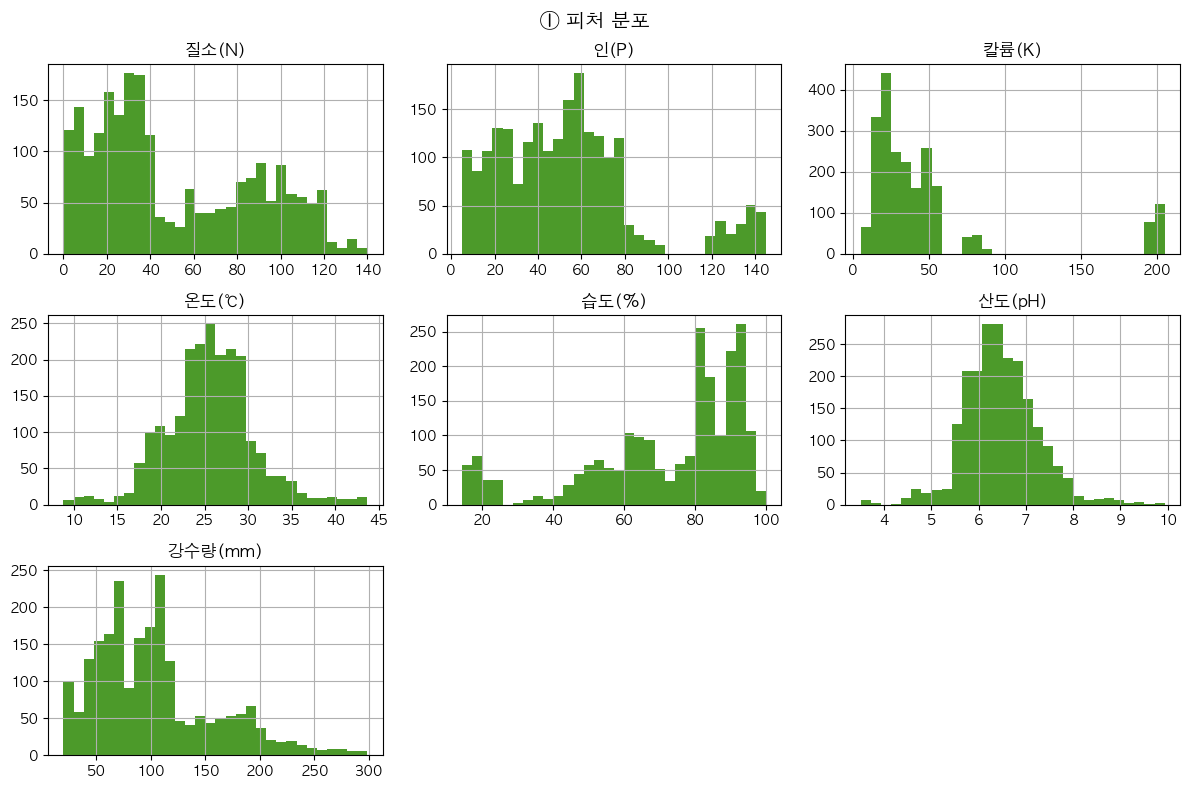

In [7]:
# ① 피처 분포 (히스토그램) — 각 환경값이 어떤 범위에 몰려 있나
df[FEATURES].rename(columns=FEATURE_KO).hist(bins=30, figsize=(12, 8), color="#4C9A2A")
plt.suptitle("① 피처 분포", fontsize=14)
plt.tight_layout()
plt.show()

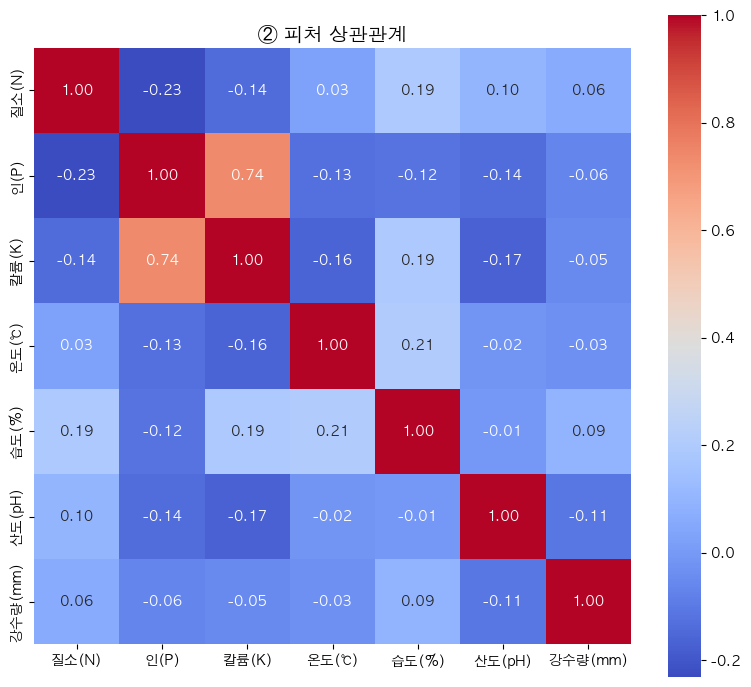

=== 상관계수 0.3 이상 (눈에 띄는 연관) ===
P  K    0.74


In [8]:
# ② 상관관계 heatmap — 어떤 피처끼리 함께 움직이나
corr = df[FEATURES].corr()
plt.figure(figsize=(8, 7))
sns.heatmap(corr.rename(index=FEATURE_KO, columns=FEATURE_KO),
            annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("② 피처 상관관계", fontsize=14)
plt.tight_layout()
plt.show()

print("=== 상관계수 0.3 이상 (눈에 띄는 연관) ===")
pairs = corr.abs().unstack().sort_values(ascending=False)
pairs = pairs[pairs < 1].drop_duplicates()
print(pairs[pairs >= 0.3].round(2).to_string() or "(없음)")

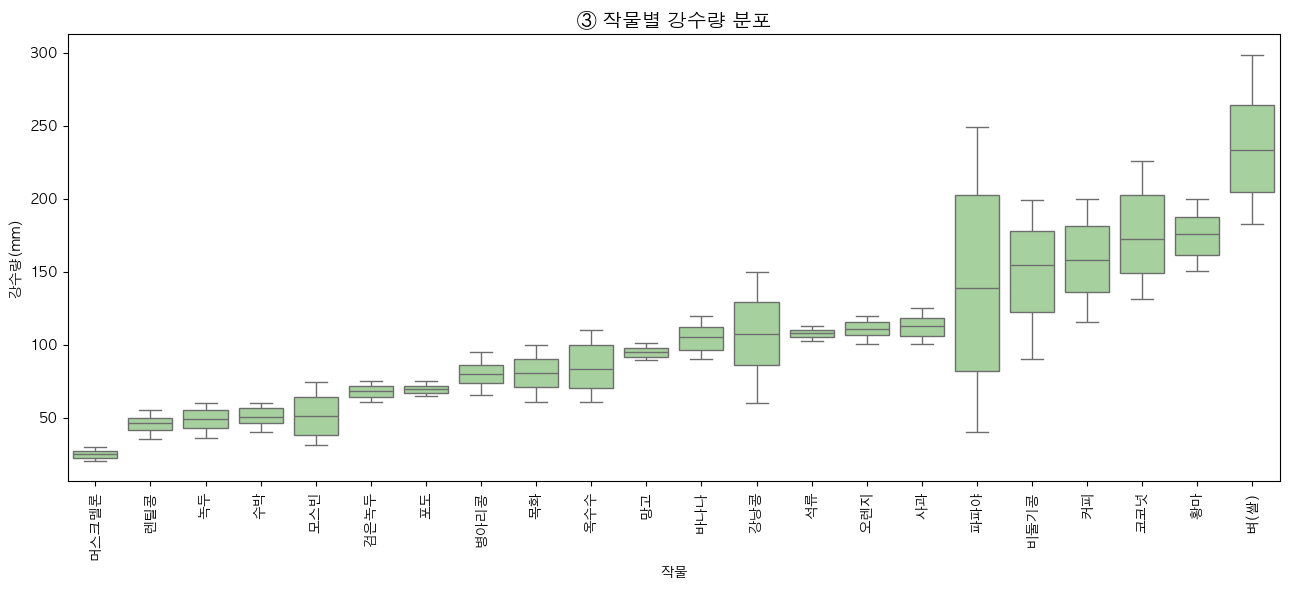

In [9]:
# ③ 작물별 강수량 분포 (중앙값 순) — 작물마다 선호 환경이 다름을 확인
order = df.groupby("label")["rainfall"].median().sort_values().index
plt.figure(figsize=(13, 6))
sns.boxplot(data=df, x="label", y="rainfall", order=order, color="#A0D995")
plt.xticks(range(len(order)), [ko_crop(c) for c in order], rotation=90)
plt.xlabel("작물"); plt.ylabel("강수량(mm)")
plt.title("③ 작물별 강수량 분포", fontsize=14)
plt.tight_layout()
plt.show()

## 3. 전처리

세 가지 처리를 함수(`prepare_data`)로 묶어 모델들이 똑같은 데이터로 학습하게 한다.

1. **인코딩**: 작물 문자(rice…) → 숫자 (모델은 숫자만 처리)
2. **train/test 분리**: stratify로 22종 비율을 양쪽에 동일하게 유지
3. **스케일링**: train에만 `fit` → test는 그 기준으로 변환만 (★데이터 누수 방지)

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

def prepare_data(test_size=0.2, random_state=42, scale=True):
    df = pd.read_csv(CSV)
    X = df.drop(columns=["label"])     # 입력 피처 7개
    y_raw = df["label"]                # 정답 (문자)

    le = LabelEncoder()                # ① 인코딩
    y = le.fit_transform(y_raw)

    X_train, X_test, y_train, y_test = train_test_split(   # ② 분리 (비율 유지)
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    scaler = None                      # ③ 스케일링 (train에만 fit)
    if scale:
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)
    return X_train, X_test, y_train, y_test, le, scaler

X_train, X_test, y_train, y_test, le, scaler = prepare_data()

print("① 인코딩 (앞 5개):", dict(zip(le.classes_[:5], range(5))), f"... 총 {len(le.classes_)}종")
print(f"② train/test 분리: train {X_train.shape[0]}개 / test {X_test.shape[0]}개 (피처 {X_train.shape[1]}개)")
print("③ 스케일링 후 train 평균≈0, 표준편차≈1:")
print("   평균    :", np.round(X_train.mean(axis=0), 2))
print("   표준편차:", np.round(X_train.std(axis=0), 2))

① 인코딩 (앞 5개): {'apple': 0, 'banana': 1, 'blackgram': 2, 'chickpea': 3, 'coconut': 4} ... 총 22종
② train/test 분리: train 1760개 / test 440개 (피처 7개)
③ 스케일링 후 train 평균≈0, 표준편차≈1:
   평균    : [ 0.  0.  0. -0. -0. -0.  0.]
   표준편차: [1. 1. 1. 1. 1. 1. 1.]


모델마다 반복되는 평가(정확도·작물별 리포트·혼동행렬)를 함수로 묶는다.

In [11]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def evaluate(model, name):
    """학습된 model로 예측 → 정확도·리포트 출력 + 혼동행렬 그림. 정확도 반환."""
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"① 정확도(Accuracy): {acc:.4f}  ({acc:.1%})")
    print("\n② 작물별 상세 (precision/recall/f1)")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    cm = confusion_matrix(y_test, y_pred)
    labels_ko = [ko_crop(c) for c in le.classes_]
    plt.figure(figsize=(11, 9))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
                xticklabels=labels_ko, yticklabels=labels_ko, cbar=False, square=True)
    plt.xlabel("예측"); plt.ylabel("실제")
    plt.title(f"③ 혼동행렬 — {name}", fontsize=14)
    plt.tight_layout(); plt.show()
    return acc

def plot_importance(importances, name):
    """피처 중요도 막대그래프 (트리 모델 전용)."""
    order = np.argsort(importances)[::-1]
    print("④ 피처 중요도 (작물 가르기 기여도)")
    for i in order:
        print(f"   {FEATURE_KO[FEATURES[i]]:10s} {importances[i]:.3f}")
    plt.figure(figsize=(8, 5))
    sns.barplot(x=importances[order], y=[FEATURE_KO[FEATURES[i]] for i in order], color="#4C9A2A")
    plt.xlabel("중요도"); plt.title(f"④ 피처 중요도 — {name}", fontsize=14)
    plt.tight_layout(); plt.show()

## 4. 모델 ① LogisticRegression

분류 입문용. '선'으로 클래스를 가르는 가장 기본 모델 — 기준선(baseline)으로 삼는다.

① 정확도(Accuracy): 0.9727  (97.3%)

② 작물별 상세 (precision/recall/f1)
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       0.95      1.00      0.98        20
    chickpea       1.00      1.00      1.00        20
     coconut       0.95      1.00      0.98        20
      coffee       1.00      1.00      1.00        20
      cotton       0.95      1.00      0.98        20
      grapes       1.00      1.00      1.00        20
        jute       0.83      1.00      0.91        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.94      0.85      0.89        20
       maize       1.00      0.95      0.97        20
       mango       0.95      1.00      0.98        20
   mothbeans       0.90      0.90      0.90        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange    

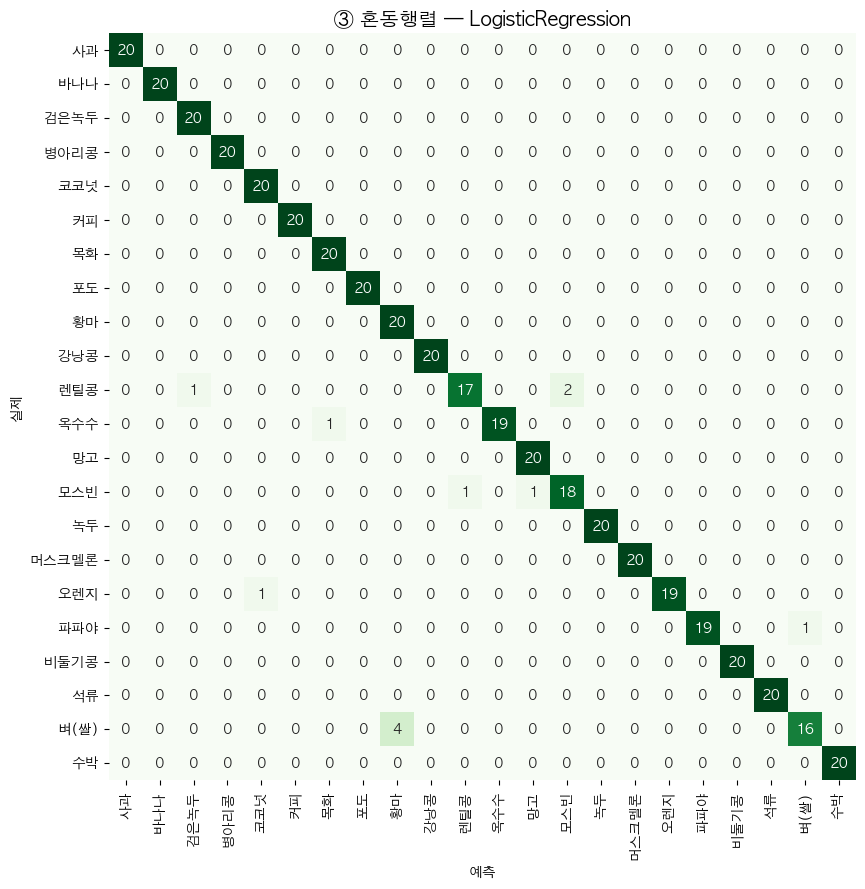

In [12]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=1000)   # 수렴 경고 방지로 반복 늘림
logreg.fit(X_train, y_train)
acc_logreg = evaluate(logreg, "LogisticRegression")

## 5. 모델 ② RandomForest

'결정나무 여러 그루의 투표'. LogReg가 직선으로 못 떼낸 헷갈림(rice↔jute 등)을 개선하는지 본다.
트리 모델이라 **피처 중요도**도 같이 확인.

① 정확도(Accuracy): 0.9955  (99.5%)

② 작물별 상세 (precision/recall/f1)
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange    

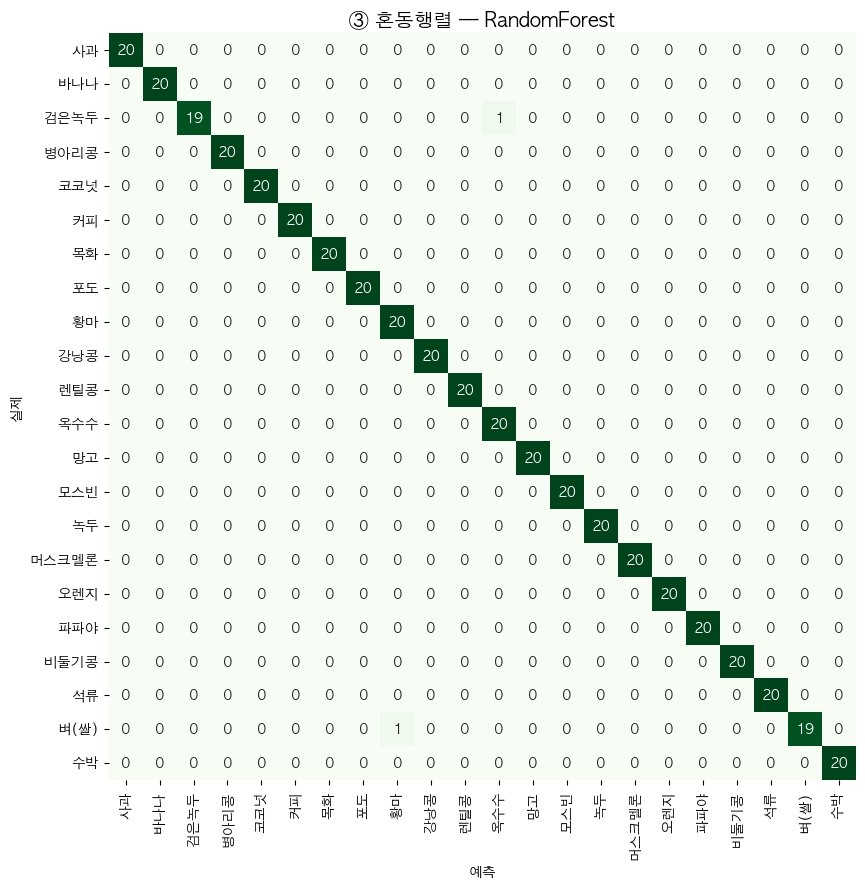

④ 피처 중요도 (작물 가르기 기여도)
   강수량(mm)    0.220
   습도(%)      0.217
   칼륨(K)      0.181
   인(P)       0.151
   질소(N)      0.103
   온도(℃)      0.075
   산도(pH)     0.052


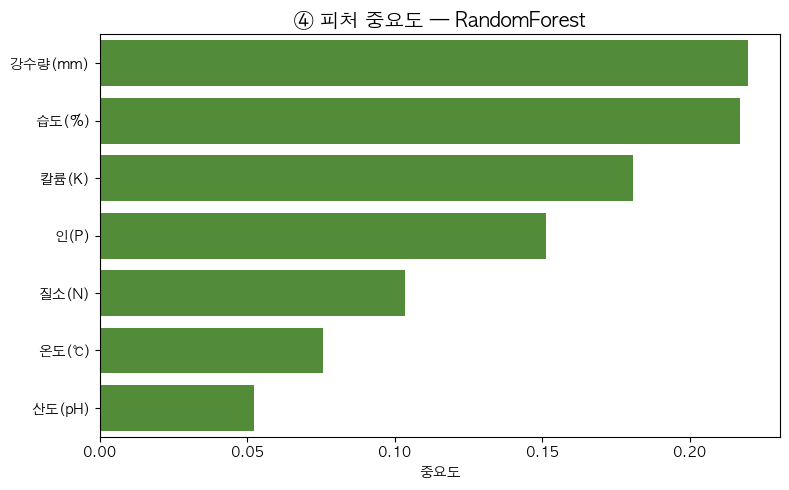

In [13]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)   # 나무 200그루
rf.fit(X_train, y_train)
acc_rf = evaluate(rf, "RandomForest")
plot_importance(rf.feature_importances_, "RandomForest")

## 6. 모델 ③ XGBoost

'부스팅' 트리 — 앞 나무의 실수를 다음 나무가 보완하며 순차로 키운다(오답에 집중).

① 정확도(Accuracy): 0.9932  (99.3%)

② 작물별 상세 (precision/recall/f1)
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.90      0.95        20
       maize       1.00      1.00      1.00        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.95      1.00      0.98        20
    mungbean       0.95      1.00      0.98        20
   muskmelon       1.00      1.00      1.00        20
      orange    

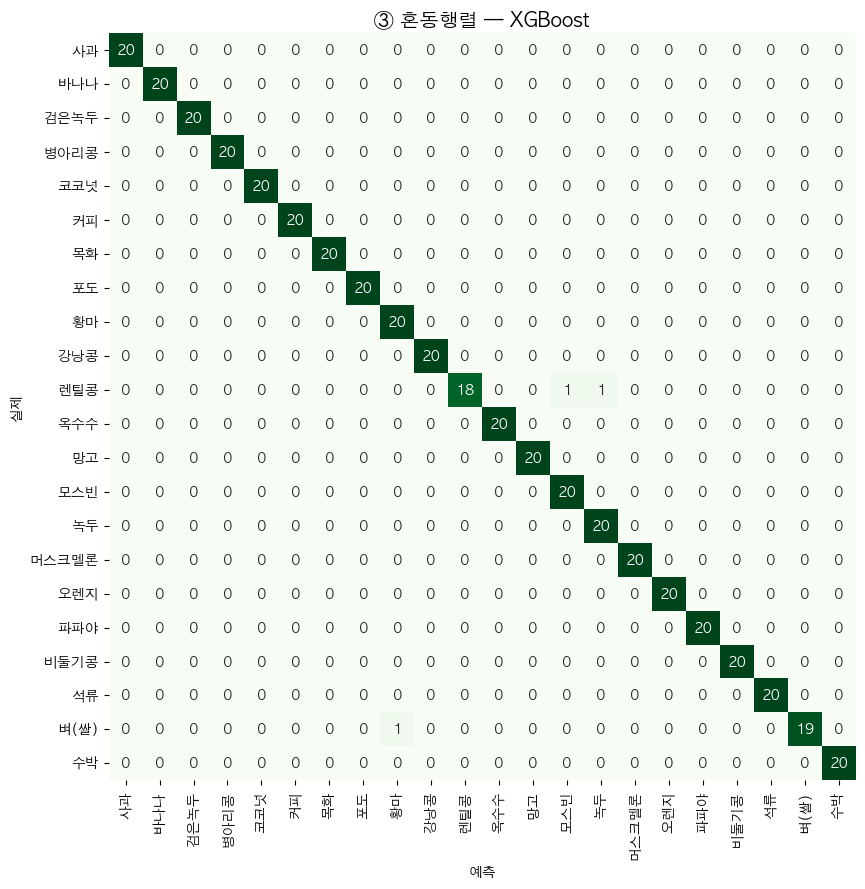

④ 피처 중요도 (작물 가르기 기여도)
   인(P)       0.206
   칼륨(K)      0.190
   습도(%)      0.160
   질소(N)      0.160
   강수량(mm)    0.153
   온도(℃)      0.073
   산도(pH)     0.058


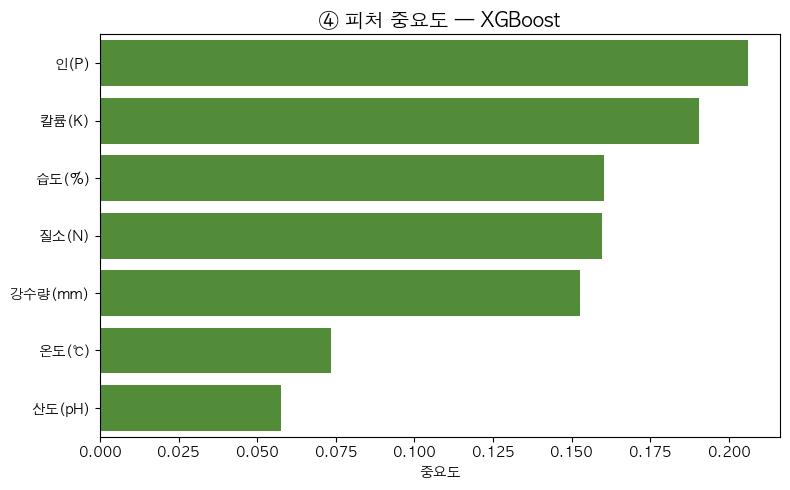

In [14]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=200, random_state=42, n_jobs=-1)
xgb.fit(X_train, y_train)
acc_xgb = evaluate(xgb, "XGBoost")
plot_importance(xgb.feature_importances_, "XGBoost")

## 7. 세 모델 비교 → 베스트 선정

세 모델의 test 정확도를 한눈에 비교하고, 배포(Streamlit 데모)에 쓸 모델을 고른다.

=== 세 모델 정확도 비교 ===
   RandomForest         0.9955  (99.5%)  ⭐ 베스트
   XGBoost              0.9932  (99.3%)
   LogisticRegression   0.9727  (97.3%)


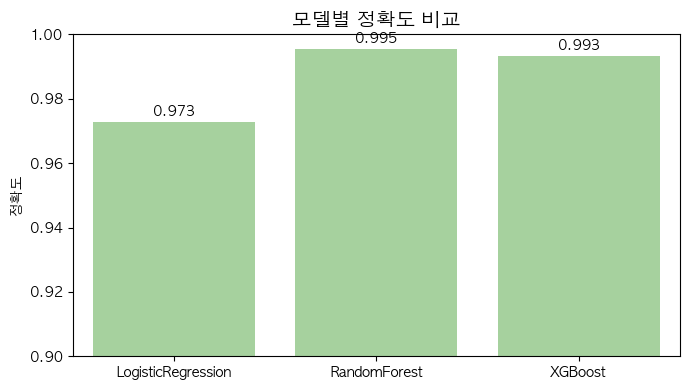


베스트 모델 = RandomForest (99.5%) → Streamlit 데모(app.py)에 사용


In [15]:
scores = {"LogisticRegression": acc_logreg, "RandomForest": acc_rf, "XGBoost": acc_xgb}
best = max(scores, key=scores.get)

print("=== 세 모델 정확도 비교 ===")
for name, s in sorted(scores.items(), key=lambda kv: kv[1], reverse=True):
    print(f"   {name:20s} {s:.4f}  ({s:.1%})" + ("  ⭐ 베스트" if name == best else ""))

names, vals = list(scores.keys()), list(scores.values())
plt.figure(figsize=(7, 4))
bars = sns.barplot(x=names, y=vals, color="#A0D995")
plt.ylim(0.9, 1.0)   # 차이가 잘 보이게 90%부터
for i, v in enumerate(vals):
    bars.text(i, v + 0.002, f"{v:.3f}", ha="center")
plt.ylabel("정확도"); plt.title("모델별 정확도 비교", fontsize=14)
plt.tight_layout(); plt.show()

print(f"\n베스트 모델 = {best} ({scores[best]:.1%}) → Streamlit 데모(app.py)에 사용")

## 8. 모델 저장 (학습 ↔ 서빙 분리)

여기서 딱 한 번 학습 → `.pkl`로 저장. Streamlit 데모는 이 파일을 **불러와 예측만** 한다(재학습 X).

**묶음 3종**(예측에 모두 필요): `model`(환경값→작물번호) · `scaler`(입력을 학습 때와 같은 잣대로) · `le`(작물번호→이름 복원).
+ 작물별 환경 프로파일(평균·최소·최대)도 같이 저장해 데모의 '환경 가이드'에 사용한다.

In [16]:
import joblib

MODELS = ROOT / "models"
MODELS.mkdir(exist_ok=True)

# 배포에 쓸 베스트 모델 = RandomForest (안정적·해석 쉬움). 전체 데이터로 한 번 더 학습.
best_model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
best_model.fit(X_train, y_train)

# 작물별 환경 프로파일 (원본 CSV는 배포에 안 올리므로 집계값만 묶어 보냄)
prof_mean = df.groupby("label")[FEATURES].mean().round(1)
prof_min  = df.groupby("label")[FEATURES].min().round(1)
prof_max  = df.groupby("label")[FEATURES].max().round(1)

bundle = {
    "model": best_model, "scaler": scaler, "le": le,
    "prof_mean": prof_mean, "prof_min": prof_min, "prof_max": prof_max,
}
out = MODELS / "phase1_crop_rf.pkl"
joblib.dump(bundle, out)

print("저장 완료 →", out)
print(f"  - model : {type(best_model).__name__} (트리 {best_model.n_estimators}그루)")
print(f"  - scaler: {type(scaler).__name__}")
print(f"  - le    : 작물 {len(le.classes_)}종")
print(f"  - 프로파일: 작물 {len(prof_mean)}종 × 피처 {len(FEATURES)}개 (평균·최소·최대)")

저장 완료 → /Users/jeongjaebong/IntelliJ/mycode/toy_project/solo/smartfarm_ai/models/phase1_crop_rf.pkl
  - model : RandomForestClassifier (트리 200그루)
  - scaler: StandardScaler
  - le    : 작물 22종
  - 프로파일: 작물 22종 × 피처 7개 (평균·최소·최대)


---
저장된 `models/phase1_crop_rf.pkl` 을 `app.py`(Streamlit 데모)가 불러와 슬라이더 입력 → 작물 추천을 수행한다.